# Introducción a los Algoritmos Genéticos

En los temas anteriores estudiamos **algoritmos de búsqueda en espacios discretos** (BFS, DFS, A*, etc.), donde el problema estaba completamente descrito a partir de un **grafo** o un conjunto de estados y acciones bien definidos. Estos métodos trabajan de manera **determinista**, explorando caminos hasta encontrar la solución óptima (o aceptable) según un criterio de coste o heurística.

En contraste, los **algoritmos genéticos (GA, por sus siglas en inglés)** pertenecen a la familia de los **modelos evolutivos**. En lugar de recorrer explícitamente todos los estados posibles, se inspiran en los principios de la **evolución biológica**:

- Una población de posibles soluciones se representa como “individuos”.
- Cada individuo tiene un “cromosoma” que codifica una solución candidata.
- La evolución de la población se guía por operadores como **selección**, **cruce (crossover)** y **mutación**.
- Con cada generación se espera que emerjan soluciones cada vez mejores, no por exploración exhaustiva, sino por un proceso de adaptación y variación.

Este enfoque es especialmente útil cuando:
- El espacio de búsqueda es muy amplio o poco estructurado.
- No se dispone de una descripción clara de estados y transiciones.
- Se busca una solución “suficientemente buena” en lugar de la óptima exacta.

---

### Nota histórica
Los algoritmos genéticos fueron popularizados en los años 1970 por **John Holland**, investigador de la Universidad de Míchigan, quien los propuso como una técnica computacional inspirada en la evolución darwiniana. Desde entonces, se han aplicado en múltiples áreas: optimización de funciones, diseño de ingeniería, aprendizaje automático y problemas complejos donde otros métodos de búsqueda fracasan o resultan demasiado costosos.

In [18]:
#importar numpy, matplotlib
import numpy as np 
import matplotlib.pyplot as plt 


## Ejemplo ilustrativo: maximización de una función multimodal

Consideremos el problema de encontrar el valor de $x \in [0, 10]$ que **maximiza** la función:

$$
f(x) = x  \sin(2 \pi x) + 1
$$




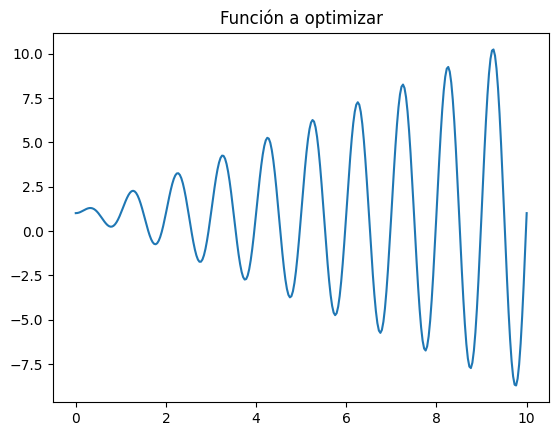

In [19]:
#fraficar la función en el rango solicitado 
x1 = np.linspace(0,10,300)
plt.plot(x1, x1*np.sin(2*np.pi*x1)+1)
plt.title('Función a optimizar')
plt.show()

# Objetivo y componentes de un Algoritmo Genético

### Objetivo principal
El objetivo de un **algoritmo genético (GA)** es **encontrar soluciones aproximadas de buena calidad** a problemas de optimización, especialmente cuando:
- El espacio de búsqueda es muy grande o no está bien estructurado.
- El problema tiene múltiples óptimos locales.
- No se dispone de un método analítico o determinista eficiente.

En lugar de buscar una única trayectoria en un grafo (como en A* o DFS), el GA mantiene y hace evolucionar **una población de soluciones candidatas**, utilizando principios inspirados en la evolución biológica.

---

### Componentes esenciales de un GA

1. **Representación (codificación)**
   - Define cómo se describe cada solución candidata.
   - Puede ser una cadena binaria, un vector de números reales, una permutación, etc.
   - Ejemplo: representar un número $x$ en el intervalo $[0,10]$ con 8 bits.

2. **Población inicial**
   - Conjunto inicial de soluciones candidatas (individuos).
   - Suele generarse de manera aleatoria para garantizar diversidad.

3. **Función de aptitud (fitness function)**
   - Mide la calidad de cada individuo como solución al problema.
   - Es la base para decidir qué individuos sobreviven o se reproducen.
   - Ejemplo: en maximización, el fitness puede ser directamente $f(x)$.

4. **Selección**
   - Mecanismo que elige los individuos con mayor probabilidad de reproducirse.
   - Se inspira en la "supervivencia del más apto".
   - Ejemplos: selección proporcional, torneo, ruleta. Daremos más detalles sobre esto abajo. 

5. **Operadores genéticos**
   - **Cruce (crossover):** combina partes de dos padres para producir nuevos hijos.
   - **Mutación:** introduce cambios aleatorios pequeños para mantener diversidad y explorar nuevas regiones del espacio.

6. **Reemplazo**
   - Define cómo se forma la nueva población a partir de los padres y los descendientes.
   - Puede ser reemplazo total (generacional) o parcial (elitismo, steady-state).

7. **Criterio de paro**
   - Establece cuándo termina la ejecución del algoritmo.
   - Ejemplos: número máximo de generaciones, alcanzar un nivel de fitness deseado, o falta de mejora en varias iteraciones.



In [20]:
#proponer solución por GA al problema 

### Solución Ejemplo Ilustrativo con GA


- **Planteamiento del problema:** maximizar $$f(x)=x\sin(10\pi x)+1$$ sujeto a la restricción $$x\in[0,10].$$ 

- Usaremos **codificación real**: cada individuo es un escalar $x\in[0,10]$.  

- **Población inicial:** Generar $N$ candidatos uniformemente en $[0,10]$ para asegurar diversidad inicial. Tomaremos $30 \leq N \leq 60$.

- **Función de aptitud:** Será directamente $$\text{fitness}(x)=f(x)=x\sin(10\pi x)+1.$$

- **Seleccion:** Usaremos **torneo** (robusto y simple): Se eligen $k$ individuos al azar (p.ej. $k=3$) y pasa el mejor como “progenitor”. Repetir para formar las parejas de cruce.

- **Cruce:** Para codificación real, usar **cruce aritmético** (una alternativa es **BLX-$\alpha$**). Dados padres $x^{(1)},x^{(2)}$, hijo
  $$x^{(\text{hijo})}=\lambda\,x^{(1)}+(1-\lambda)\,x^{(2)},\quad \lambda\sim\mathcal{U}[0,1].$$
**Probabilidad de cruce:** $p_c\in[0.7,0.9]$.

- **Mutacion:** Usaremos una perturbación **gaussiana**  
$$x\leftarrow x+\eta,\quad \eta\sim\mathcal{N}(0,\sigma^2).$$
Se sugiere $\sigma\in[0.05,0.2]$. Se debe ajustar $x$ a $[0,10]$ tras cruce/mutación.
**Probabilidad de mutación:** $p_m\in[0.05,0.2]$ por individuo.

- **Elitismo:** conservar al menos el **mejor 1–2 individuos** (copia directa a la próxima generación) para no perder la mejor solución hallada.

- **Criterio de paro:** Terminar cuando se cumpla tenga un número de generaciones $G$ alcanzado (p.ej., $G\in[50,150]$) o no hay mejora del mejor fitness durante $g$ generaciones consecutivas.


## Seudocódigo

1. **Inicializar** población $P_0=\{x_i^{(0)}\}_{i=1}^N\sim\mathcal{U}[0,10]$.
2. **Evaluar** aptitudes $\{f(x_i^{(t)})\}$.
3. **Guardar élite**: $E_t=\text{top 1–2 de }P_t$.
4. **Repetir** hasta criterio de paro:
   1. Construir nueva población $P_{t+1}$:
      - Mientras $|P_{t+1}|<N$:
        - **Selección** (torneo) para elegir dos padres.
        - Con prob. $p_c$, **cruce** $\Rightarrow$ 1–2 hijos; si no, clonar padres.
        - **Mutación** sobre hijos con prob. $p_m$; **reparar** a $[0,10]$.
        - **Evaluar** fitness de los nuevos.
        - Añadir a $P_{t+1}$.
      - Insertar **élite $E_t$** (reemplazando los peores si es necesario).
   2. Actualizar $t\leftarrow t+1$.
5. **Devolver** el mejor individuo observado $\hat{x}$ y su valor $f(\hat{x})$.







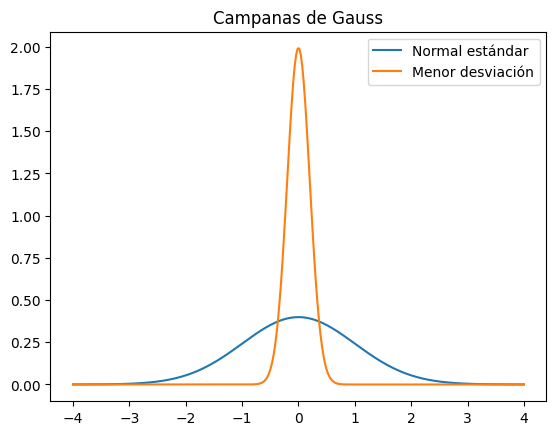

In [21]:
#Recordemos la campana de Gauss de las mutaciones
from scipy.stats import norm 
t1 = np.linspace(-4, 4, 300)
plt.plot(t1, norm.pdf(t1), label='Normal estándar')
plt.plot(t1, norm(0, 0.2).pdf(t1), label='Menor desviación')
plt.title('Campanas de Gauss')
plt.legend()
plt.show()

In [22]:
#implementar algoritmo 
f = lambda x: x*np.sin(2*np.pi*x) +1
#generador de números aleatoria 
gna = np.random.default_rng() #semilla 123 para el generador 
N = 30 #tamaño de la población 
G = 50 #número de generaciones 
p_c = 0.9 #probabilidad de cruce
p_m = 0.05 #probabilidad mutación
sigma = 0.1 #desviación de la mutación gaussiana 
pob = gna.uniform(0,10, N)
fit = f(pob) #evaluamos aptitud en la población inicial 
k = 4 #tamaño del torneo 
def Torneo(fit, k):
    """La función retorna el índice del más apto del torneo de tamaño k"""
    cand = gna.integers(0, len(fit), k)
    return cand[np.argmax(fit[cand])]
for _ in range(G):
    elite = pob[np.argmax(fit)]
    nueva_pob = [elite] 
    while len(nueva_pob)< N:
        p1 = Torneo(fit, k); p2 = Torneo(fit, k)
        if gna.uniform(0,1) < p_c:
            l = gna.uniform(0,1)
            h1 = l*p1 + (1-l)*p2
            h2 = (1-l)*p1 + l*p2
        else:
            h1, h2 = p1, p2
        if gna.uniform(0,1)<p_m:
            h1 += gna.normal(0,sigma)
            h2 += gna.normal(0,sigma)
        nueva_pob += [np.clip(h1, 0, 10), np.clip(h2,0, 10)]
    pob = np.array(nueva_pob)
    fit = f(pob)

pob[np.argmax(fit)]
        

np.float64(9.266607767362888)

In [23]:
#fraficar la función en el rango solicitado 
gna.uniform(0,1)

0.15892347425422937

**Ejercicio:** Maximiza

$$f(x,y) = x\sin(10\pi x) + y\sin(10\pi y) + 2$$
sujeto a
$$x\in[0,10],\quad y\in[0,10].$$

Instrucciones mínimas:

- Representación: individuo = vector $[x, y]$ real.
- Población inicial: N puntos uniformes en $[0,10]^2$.
- Fitness: $f(x,y)$.
- Selección: torneo con $k=3$.
- Cruce: aritmético componente a componente con $\lambda\sim U[0,1]$.
- Mutación: gaussiana por componente (desv. σ), luego clip a $[0,10]$.
- Elitismo: conservar top-2.
- Paro: G generaciones o sin mejora g generaciones.




In [24]:
# solución manual con numpy para el caso bidimensional [x, y]

def f_xy(P):
    """Evalúa f(x,y) para un individuo [x,y] o para una población Nx2."""
    P = np.asarray(P)
    x = P[..., 0]
    y = P[..., 1]
    return x*np.sin(10*np.pi*x) + y*np.sin(10*np.pi*y) + 2

# generador aleatorio con semilla fija para poder reproducir el experimento
gna = np.random.default_rng(123)

# parámetros del algoritmo genético
N = 40          # tamaño de la población
G = 100         # máximo número de generaciones
p_c = 0.9       # probabilidad de cruce
p_m = 0.10      # probabilidad de mutación por componente
sigma = 0.10    # desviación de la mutación gaussiana
k = 3           # tamaño del torneo
n_elite = 2     # elitismo: conservar top-2
paciencia = 20  # parar si no mejora en estas generaciones

# población inicial: N puntos uniformes en [0,10]^2
pob = gna.uniform(0, 10, size=(N, 2))
fit = f_xy(pob)


def Torneo(fit, k):
    """Retorna el índice del mejor individuo dentro de un torneo de tamaño k."""
    candidatos = gna.integers(0, len(fit), size=k)
    return candidatos[np.argmax(fit[candidatos])]


mejor_global = pob[np.argmax(fit)].copy()
mejor_fit_global = fit.max()
sin_mejora = 0
hist_mejor = [mejor_fit_global]

for gen in range(G):
    # ordenamos la población por fitness para extraer la élite
    idx_orden = np.argsort(fit)
    elite = pob[idx_orden[-n_elite:]].copy()

    nueva_pob = [ind.copy() for ind in elite]

    while len(nueva_pob) < N:
        # selección por torneo: elegimos índices y luego tomamos los vectores padres
        i1 = Torneo(fit, k)
        i2 = Torneo(fit, k)
        p1 = pob[i1].copy()
        p2 = pob[i2].copy()

        # cruce aritmético componente a componente
        if gna.uniform(0, 1) < p_c:
            lam = gna.uniform(0, 1, size=2)
            h1 = lam*p1 + (1 - lam)*p2
            h2 = (1 - lam)*p1 + lam*p2
        else:
            h1, h2 = p1.copy(), p2.copy()

        # mutación gaussiana por componente
        mask1 = gna.uniform(0, 1, size=2) < p_m
        mask2 = gna.uniform(0, 1, size=2) < p_m
        h1[mask1] += gna.normal(0, sigma, size=mask1.sum())
        h2[mask2] += gna.normal(0, sigma, size=mask2.sum())

        # reparar: obligamos a que cada componente quede en [0,10]
        h1 = np.clip(h1, 0, 10)
        h2 = np.clip(h2, 0, 10)

        nueva_pob.append(h1)
        if len(nueva_pob) < N:
            nueva_pob.append(h2)

    # actualizamos población y fitness
    pob = np.array(nueva_pob)
    fit = f_xy(pob)

    # registramos el mejor de la generación
    mejor_gen = pob[np.argmax(fit)].copy()
    mejor_fit_gen = fit.max()
    hist_mejor.append(mejor_fit_gen)

    if mejor_fit_gen > mejor_fit_global:
        mejor_global = mejor_gen.copy()
        mejor_fit_global = mejor_fit_gen
        sin_mejora = 0
    else:
        sin_mejora += 1

    if sin_mejora >= paciencia:
        print(f'Paro temprano en la generación {gen+1}: no hubo mejora en {paciencia} generaciones.')
        break

print('Mejor individuo encontrado [x, y]:', mejor_global)
print('Mejor fitness encontrado:', mejor_fit_global)
print('Valor de f en el mejor individuo:', f_xy(mejor_global))
print('Último mejor fitness por generación:', hist_mejor[-10:])



Mejor individuo encontrado [x, y]: [9.05011178 5.25018005]
Mejor fitness encontrado: 16.30015203726253
Valor de f en el mejor individuo: 16.30015203726253
Último mejor fitness por generación: [np.float64(16.159412214669807), np.float64(16.159412214669807), np.float64(16.300082901288185), np.float64(16.300082901288185), np.float64(16.300082901288185), np.float64(16.300082901288185), np.float64(16.300082901288185), np.float64(16.30014617696522), np.float64(16.300146384287935), np.float64(16.30015203726253)]


## Operadores genéticos: selección, cruce y mutación

Los algoritmos genéticos se basan en la idea de evolución por selección natural. Tres componentes clave permiten que la población evolucione generación tras generación:



### 1. Selección de padres

Define **quién se reproduce**. La idea es favorecer a los individuos con mejor desempeño (fitness), pero permitiendo algo de azar para mantener diversidad.

**Formas comunes de selección:**

- **Torneo**: se seleccionan $k$ individuos al azar y gana el de mayor fitness.  
  - Sencillo y eficaz. El parámetro $k$ controla la presión selectiva.  
  - Muy utilizado en la práctica.

- **Ruleta (proporcional al fitness)**: cada individuo tiene una probabilidad proporcional a su aptitud.  
  - Puede ser inestable si hay gran desigualdad de fitness.

- **Ranking**: se asignan probabilidades en función del orden, no del valor absoluto del fitness.  
  - Estabiliza la presión selectiva.

- **Stochastic Universal Sampling (SUS)**: mejora la ruleta, distribuyendo mejor las oportunidades.



### 2. Cruce (crossover)

Combina la información genética de dos padres para generar nuevos individuos.

**Para codificación binaria:**
- **Cruce de 1 punto**: se intercambian los bits a partir de una posición aleatoria.
- **Cruce de 2 puntos**: se intercambia la sección entre dos posiciones.
- **Cruce uniforme**: cada bit del hijo se elige al azar de uno de los dos padres.

**Para codificación real:**
- **Cruce aritmético**: el hijo es una combinación lineal de los padres:
  $$
  x_{\text{hijo}} = \lambda x_1 + (1-\lambda) x_2,\quad \lambda\sim \mathcal{U}[0,1]
  $$
- **BLX-$\alpha$**: permite explorar un rango más amplio entre los padres.
- **Simulated Binary Crossover (SBX)**: simula el comportamiento de cruces binarios sobre valores reales, manteniendo diversidad.



### 3. Mutación

Introduce **variabilidad aleatoria** para evitar convergencia prematura y explorar nuevas regiones del espacio de búsqueda.

**Para codificación binaria:**
- **Mutación por bit (flip)**: se invierte cada bit con una probabilidad pequeña, usualmente $p_m \approx \frac{1}{n}$.

**Para codificación real:**
- **Mutación gaussiana**: se añade ruido normal a cada componente:
  $$
  x \leftarrow x + \eta,\quad \eta \sim \mathcal{N}(0, \sigma^2)
  $$
- **Mutación uniforme**: se reemplaza el valor por uno nuevo aleatorio dentro del dominio.



Un buen diseño de un algoritmo genético **equilibra** estos tres componentes según el problema.


In [25]:
p1 = np.array([1,1,0,0,0,1]) ; p2 = np.array([1,1,1,0,1,1])
list(p1[:3]) + list(p2[3:])

[np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1)]

# Ejemplo: problema de la mochila para una salida de camping

Una persona se prepara para una salida de **camping** y debe decidir qué ítems llevar en su mochila.  
Cada objeto tiene un **peso (kg)** y una **utilidad (valor subjetivo)** para el viaje.  
La mochila tiene una **capacidad máxima de 14 kg**.

El objetivo es **maximizar el valor total** de los ítems llevados, sin exceder el peso permitido.

## Datos del problema

| Ítem           | Peso (kg) | Valor |
|----------------|-----------|-------|
| Gafas de sol   | 1.0       | 7     |
| Navaja         | 0.5       | 10    |
| Botiquín       | 3.0       | 13    |
| Agua (2L)      | 4.0       | 12    |
| Lámpara        | 2.5       | 9     |
| Saco de dormir | 5.0       | 15    |
| GPS            | 1.5       | 8     |
| Comida         | 3.5       | 14    |
| Impermeable    | 2.0       | 6     |
| Mapa físico    | 0.3       | 4     |

Capacidad máxima:  
$$
C = 14 \;\text{kg}
$$

## Formulación

Variables binarias:  
$$
x_i = 
\begin{cases}
1 & \text{si el ítem } i \text{ se lleva},\\
0 & \text{si no}.
\end{cases}
$$

Función objetivo:  
$$
\max\;\; \sum_{i=1}^{10} v_i x_i
\quad \text{s.a.} \quad
\sum_{i=1}^{10} w_i x_i \le 14.
$$

donde $v_i$ y $w_i$ son el valor y el peso del ítem $i$ respectivamente.

## Ejemplo de solución factible

Una solución como  
$$
x = (1, 1, 0, 1, 0, 1, 0, 0, 0, 1)
$$
representa llevar: gafas, navaja, agua, saco de dormir y mapa.

Peso total:  
$$
1.0 + 0.5 + 4.0 + 5.0 + 0.3 = 10.8 \;\text{kg}
$$

Valor total:  
$$
7 + 10 + 12 + 15 + 4 = 48
$$

Es factible (peso ≤ 14) y se puede comparar con otras soluciones generadas por el algoritmo genético.


In [26]:
#proponer solución al problema 
# Datos del problema
w = np.array([1.0, 0.5, 3.0, 4.0, 2.5, 5.0, 1.5, 3.5, 2.0, 0.3])  # pesos
v = np.array([7, 10, 13, 12, 9, 15, 8, 14, 6, 4])                 # valores
C = 14     # capacidad de la mochila                                        # capacidad
# Parámetros del GA
N = 20
gna = np.random.default_rng(12)
l = 12

def fitness(x):
    peso_total = np.dot(w, x)
    valor_total = np.dot(v, x)
    penalizacion = max(peso_total - C, 0) * 1  # Penalización por exceder la capacidad
    return valor_total - penalizacion
pob = gna.integers(0, 2, (N, 10))  # Población inicial
fit = np.array([fitness(ind) for ind in pob]) # vector de aptitudes de la población
k = 3 # tamano de torneo para la seleccion 

def torneo(fit, k=2):
    candidatos = gna.integers(0, len(fit), k)
    return np.argmax(fit[candidatos])

pc = 0.9
pm = 0.1
G = 50
for _ in range(G):
    elite = pob[np.argmax(fit).copy()]
    nueva_pob = [elite]

    while len(nueva_pob) < N:
        p1 = pob[torneo(fit, k)]
        p2 = pob[torneo(fit, k)]

        if gna.random() < pc:
            punto = gna.integers(1, 10)
            h1 = np.concatenate([p1[:punto], p2[punto:]]).copy()
            h2 = np.concatenate([p2[:punto], p1[punto:]]).copy() 
        else: 
            h1, h2 = p1.copy(), p2.copy()
        mask1 = gna.random(10) < pm
        mask2 = gna.random(10) < pm
        h1[mask1] = 1 - h1[mask1]
        h2[mask2] = 1 - h2[mask2]
        nueva_pob += [h1, h2]
    pob = np.array(nueva_pob[:N])
    fit = np.array([fitness(ind) for ind in pob])

x_hat = pob[np.argmax(fit)]

print("La mejor solución encontrada es:", x_hat)
print(f'Peso total: {np.dot(w, x_hat)}, Valor total: {np.dot(v, x_hat)}, Penalización: {max(np.dot(w, x_hat) - C, 0)}')
# Resultado

# a mano

La mejor solución encontrada es: [1 1 1 1 1 1 1 1 1 1]
Peso total: 23.3, Valor total: 98, Penalización: 9.3


In [27]:
# p = gna.integers(0,2,(5,10))
#f = np.array([fitness(i) for i in p ])
# h1 = p[0]
print(h1)
h1[mask1] = 1-h1[mask1]
print(h1)

[1 1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 1 1 1 1 1]


In [28]:
mask = gna.random(10) < 0.1
mask

array([False, False, False, False, False, False, False, False, False,
       False])

In [29]:
#p

In [30]:
C = 14
l = 10 # penalización 
x = gna.integers(0,2,10)
print(x)
np.dot(v,x) - max(np.dot(w,x)-C, 0), (np.dot(w,x)-C)


[1 0 1 1 1 1 1 0 1 1]


(np.float64(68.7), np.float64(5.300000000000001))

In [31]:
x = np.array([1,2,3,4])

In [32]:
# Distributed Evolutionary Algorithms in Python deap 
# pip install deap 
# import random 
# from deap import base, creator, tools, algorithms


## Problema biobjetivo de la mochila
 
Consideremos el problema de la mochila con los mismos datos del ejemplo anterior. Supongamos que hay $n$ objetos, y que cada objeto $i$, para $i=1,\dots,n$, tiene:
 
- un valor $v_i > 0$,
- un peso $w_i > 0$.
 
La decisión consiste en determinar qué objetos se incluyen en la mochila. Para ello, definimos variables binarias
$$
x_i =
\begin{cases}
1, & \text{si el objeto } i \text{ se selecciona},\\
0, & \text{si el objeto } i \text{ no se selecciona}.
\end{cases}
$$
 
Así, una solución del problema queda representada por el vector
$$
x = (x_1,\dots,x_n)\in\{0,1\}^n.
$$
 
A diferencia de la versión clásica, donde se maximiza el valor total sujeto a una restricción de capacidad, en la versión biobjetivo se consideran simultáneamente dos criterios:
 
1. **maximizar el valor total** de los objetos seleccionados,
2. **minimizar el peso total** de los objetos seleccionados.
 
Estos dos objetivos se expresan mediante las funciones
$$
f_1(x)=\sum_{i=1}^n v_i x_i,
\qquad
f_2(x)=\sum_{i=1}^n w_i x_i.
$$
 
Por tanto, el problema biobjetivo de la mochila se plantea como
$$
\max f_1(x)=\sum_{i=1}^n v_i x_i,
\qquad
\min f_2(x)=\sum_{i=1}^n w_i x_i,
$$
sujeto a
$$
x_i\in\{0,1\}, \qquad i=1,\dots,n.
$$
 
En este contexto, ya no se busca una única solución óptima, pues normalmente los dos objetivos entran en conflicto: una selección con mayor valor suele implicar también un mayor peso. Por ello, el interés se centra en identificar las soluciones **eficientes** o **no dominadas**, es decir, aquellas para las cuales no existe otra solución que mejore simultáneamente ambos criterios.
 
Diremos que una solución $x$ domina a otra solución $y$ si se cumple
$$
f_1(x)\geq f_1(y), \qquad f_2(x)\leq f_2(y),
$$
y al menos una de estas desigualdades es estricta. En consecuencia, una solución es eficiente si no es dominada por ninguna otra solución factible.

**Ejemplo** Considere las estrategias 
$$
x_1 = [1, 0, 0, 1, 1, 1, 0, 0, 1, 0],\, x_2 = [1, 1. 0, 0, 1, 1, 1, 1, 0, 1]
$$
Calculando se ve que la funcion de valor de $x_1$ es 49 y su peso es 14.5. Para la estrategia $x_2$ se tiene una funcion de valor de 67 y un peso de 14.3. Es decir **la estrategia $x_2$ domina a la estrategia $x_1$**

In [33]:
# solucion aproximada al problema biobjetivo de la mochila 
# definamos la funcion para evaluar a una estrategia

def evaluar(x):
    """La función retorna el valor de la función objetivo y el peso total de la estrategia x"""
    valor = np.dot(v, x)
    peso = np.dot(w, x)
    return valor, peso

def domina(x,y): 
    """La funcion evalua si la estrategia x domina a la estrategia y"""
    wx, vx = evaluar(x)
    wy, vy = evaluar(y)
    return ((wx < wy) and (vx >= vy)) and ((wx < wy) or (vx > vy)) 

def ranking_no_dominancia(poblacion):
    """Esta funcion toma una poblacion y devuleve un vector con tantos elementos como la poblacion
    el vector, en la posicion i, senala cuantas estrategias de la poblacion dominan a x_i"""
    ranks = np.zeros(len(poblacion), dtype=int)
    for i in range(len(poblacion)):
        for j in range(len(poblacion)):
            if i != j and domina(poblacion[j], poblacion[i]):
                ranks[i] += 1
    return ranks

gna = np.random.default_rng(12)

def torneo_no_dominancia(poblacion, k=2):
    ranks = ranking_no_dominancia(poblacion)
    candidatos = gna.integers(0, len(poblacion), k)
    return candidatos[np.argmin(ranks[candidatos])]

def frontera_pareto(pob):
    pareto = [] #almacenaremos las estrategias de pob que no son dominada
    for i in range (len(pob)):
        dominada = False
        for j in range(len(pob)):
            if i != j and domina(pob[j], pob[i]):
                dominada = True
                break
        if not dominada:
            pareto.append(pob[i])
        if len(pareto)==0:
            return np.empty((0, pob.shape[1]))
        pareto = np.unique(np.array(pareto), axis = 0)
    return pareto

# ciclo evolutivo
N, G = 30, 60 # individuos de la poblacion y numero de generaciones
pc, pm = 0.9, 0.1 # probabilidad de cruce y mutacion
pob = gna.integers(0,2, (N, 10))
historial = [] # esta lista almacenara todas las estrategias visitadas
for _ in range(G):
    ranks = ranking_no_dominancia(pob)
    elite = pob[np.argmin(ranks)].copy()
    nueva_pob = [elite]
    while len(nueva_pob) < N:
        p1 = pob[torneo_no_dominancia(pob, 3)]
        p2 = pob[torneo_no_dominancia(pob, 3)]
        if gna.random() < pc:
            punto = gna.integers(1, 10)
            h1 = np.concatenate([p1[:punto], p2[punto:]]).copy()
            h2 = np.concatenate([p2[:punto], p1[punto:]]).copy()
        else:
            h1, h2 = p1.copy(), p2.copy()
        mask1 = (gna.random(10) < pm)
        mask2 = (gna.random(10) < pm)
        h1[mask1] = 1-h1[mask1]
        h2[mask2] = 1 - h2[mask2]
        nueva_pob += [h1, h2]

    pob = np.array(nueva_pob[:N])
    historial.append(pob.copy())


    todas = np.vstack(historial)
    todas = np.unique(todas, axis = 0) # eliminamos estrategias repetidas



    

In [34]:
# creamos la frontera de Pareto
pareto = frontera_pareto(todas)
pareto.shape


AttributeError: 'numpy.ndarray' object has no attribute 'append'

In [ ]:
pesos_todas = np.array([evaluar(x)[0] for x in todas])
valores_todas = np.array([evaluar(x)[1] for x in todas])
pesos_pareto = np.array([evaluar(x)[0] for x in pareto])
valor_pareto = np.array([evaluar(x)[1] for x in pareto])

NameError: name 'pareto' is not defined

In [ ]:
# pintar de negro en el scatter la ultima poblacion

NameError: name 'pesos_pareto' is not defined

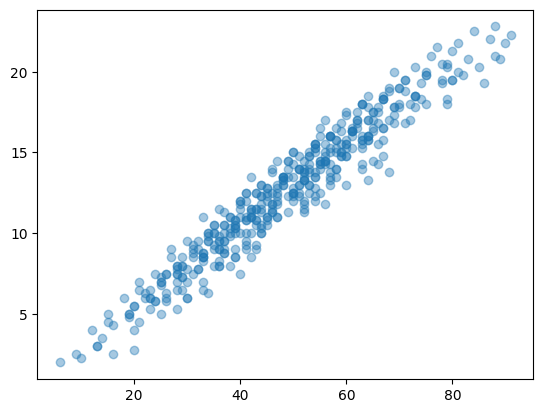

In [ ]:
plt.scatter(pesos_todas, valores_todas, alpha=0.4)
plt.scatter(pesos_pareto, valor_pareto, c='red', alpha=0.4)
plt.xlabel('Peso de cada estrategia')
plt.ylabel('Valor de cada estrategia')
plt.show()

In [ ]:
# x = np.array([1,2,3,4])
x = np.array([1,7,8,9,-1])

In [ ]:
# x = np.array([1, 2, 3, 4])
x1 = gna.integers(0,2,10)
evaluar(x1), x1

In [ ]:
x1 = gna.integers(0,2,10); x2 = gna.integers(0,2,10)
print(x1)
print(x2)
vx1 = np.dot(x1, v); wx1 = np.dot(x1, w)
vx2 = np.dot(x2, v); wx2 = np.dot(x2, w)
print(f'Valor de x1 = {vx1} y peso = {wx1}')
print(f'Valor de x2 = {np.dot(x2, v)} y peso = {np.dot(x2, w)}')

(vx1 >= vx2) and (wx1 <= wx2), (vx2 >= vx1) and (wx2 <= wx1)

[0 1 1 0 0 1 1 1 1 0]
[1 0 0 1 1 1 0 0 1 0]
Valor de x1 = 66 y peso = 15.5
Valor de x2 = 49 y peso = 14.5


(np.False_, np.False_)

In [ ]:
import random
from deap import base, creator, tools, algorithms   

In [ ]:
# se crea la caja de herramientas donde la libreria (deap) ira guardando los operadores geneticos
toolbox = base.Toolbox()
# definimos la clase FinessMax
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
# se definela clase individual. Cada individuo se representa con una lista
creator.create("Individual", list, fitness=creator.FitnessMax)
# registramos la forma de crear un 
toolbox.register("attribute", random.randint, 0, 1)
# se registra la forma de crear un individuo
# abajo se crea una lista de longitud 10
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attribute, n=10)
# abajo se crea una lista de longitud
toolbox.register("population", tools.initRepeat, list, toolbox.individual, n=50)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [ ]:
# construyamos ahora los operadores geneticos
# seleccion
toolbox.register("select", tools.selTournament, tournsize=3)
# registramos el crice por un punto
toolbox.register("mate", tools.cxOnePoint)
# registramos la mutacion. Inculimos la probabilidad de mutacion
toolbox.register("mutate", tools.mutFlipBit, indpb=0.1)
# definimos la funcion fitness de nuestro problema
w = np.array([1.0, 0.5, 3.0, 4.0, 2.5, 5.0, 1.5, 3.5, 2.0, 0.3])  # pesos
v = np.array([7, 10, 13, 12, 9, 15, 8, 14, 6, 4])                 # valores
C = 14     # capacidad de la mochila
l = 15     # penalizacion
# la funcion debe retornar una tupla, no puede ser un numero solamente
def fitness_1(x):
    peso_total = np.dot(w, x)
    valor_total = np.dot(v, x)
    penalixacion = 1 * max(peso_total - C, 0)  # Penalización por exced 
    return valor_total - penalixacion,
toolbox.register("evaluate", fitness_1)
    

In [ ]:
# analisis de estadisticas por generacion
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register('Media', np.mean)
stats.register('Desviacion', np.std)

pob = toolbox.population()
pob, logbook = algorithms.eaSimple(pob, toolbox, cxpb=0.9, mutpb=0.05, ngen=60, stats=stats, verbose=False)
logbook


[{'gen': 0,
  'nevals': 50,
  'Media': np.float64(49.482),
  'Desviacion': np.float64(14.830073364619611)},
 {'gen': 1,
  'nevals': 44,
  'Media': np.float64(61.33999999999999),
  'Desviacion': np.float64(11.112263495795986)},
 {'gen': 2,
  'nevals': 47,
  'Media': np.float64(69.538),
  'Desviacion': np.float64(8.002571836603531)},
 {'gen': 3,
  'nevals': 50,
  'Media': np.float64(77.198),
  'Desviacion': np.float64(4.892585819380178)},
 {'gen': 4,
  'nevals': 42,
  'Media': np.float64(81.36399999999999),
  'Desviacion': np.float64(4.729514139951377)},
 {'gen': 5,
  'nevals': 48,
  'Media': np.float64(83.22),
  'Desviacion': np.float64(5.839143772848893)},
 {'gen': 6,
  'nevals': 48,
  'Media': np.float64(87.046),
  'Desviacion': np.float64(2.2145166515517563)},
 {'gen': 7,
  'nevals': 42,
  'Media': np.float64(88.072),
  'Desviacion': np.float64(2.8539824806750307)},
 {'gen': 8,
  'nevals': 40,
  'Media': np.float64(88.626),
  'Desviacion': np.float64(0.5180000000000005)},
 {'gen': 9,

In [ ]:
algorithms.eaSimple(pob, toolbox, cxpb=0.9, mutpb=0.05, ngen=60)

gen	nevals
0  	0     
1  	48    
2  	49    
3  	48    
4  	48    
5  	48    
6  	42    
7  	46    
8  	44    
9  	42    
10 	41    
11 	45    
12 	43    
13 	42    
14 	46    
15 	46    
16 	43    
17 	40    
18 	44    
19 	44    
20 	46    
21 	46    
22 	42    
23 	46    
24 	48    
25 	41    
26 	44    
27 	41    
28 	45    
29 	46    
30 	46    
31 	44    
32 	42    
33 	42    
34 	47    
35 	48    
36 	48    
37 	49    
38 	38    
39 	44    
40 	46    
41 	45    
42 	46    
43 	48    
44 	46    
45 	45    
46 	46    
47 	40    
48 	46    
49 	46    
50 	48    
51 	46    
52 	42    
53 	44    
54 	44    
55 	46    
56 	50    
57 	36    
58 	44    
59 	43    
60 	33    


([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 0, 0, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 0, 0, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1,

In [ ]:
x1_hat = tools.selBest(pob, 1)[0]
print(f'El peso de la solucion aproximada es {np.dot(w, x1_hat)}')
print(f'El valor de la solucion aproximada es {np.dot(v, x1_hat)}')

El peso de la solucion aproximada es 23.3
El valor de la solucion aproximada es 98


In [ ]:
logbook

[{'gen': 0,
  'nevals': 50,
  'Media': np.float64(50.916),
  'Desviacion': np.float64(14.318734022252107)},
 {'gen': 1,
  'nevals': 50,
  'Media': np.float64(62.209999999999994),
  'Desviacion': np.float64(10.281386093324189)},
 {'gen': 2,
  'nevals': 46,
  'Media': np.float64(71.178),
  'Desviacion': np.float64(8.182109507944757)},
 {'gen': 3,
  'nevals': 44,
  'Media': np.float64(77.08599999999998),
  'Desviacion': np.float64(6.564815610510322)},
 {'gen': 4,
  'nevals': 44,
  'Media': np.float64(82.296),
  'Desviacion': np.float64(5.374717108834659)},
 {'gen': 5,
  'nevals': 43,
  'Media': np.float64(87.262),
  'Desviacion': np.float64(2.8521493649526843)},
 {'gen': 6,
  'nevals': 46,
  'Media': np.float64(88.166),
  'Desviacion': np.float64(2.5057222511683137)},
 {'gen': 7,
  'nevals': 48,
  'Media': np.float64(88.156),
  'Desviacion': np.float64(1.9449586113848283)},
 {'gen': 8,
  'nevals': 45,
  'Media': np.float64(88.49),
  'Desviacion': np.float64(1.4699999999999998)},
 {'gen': 

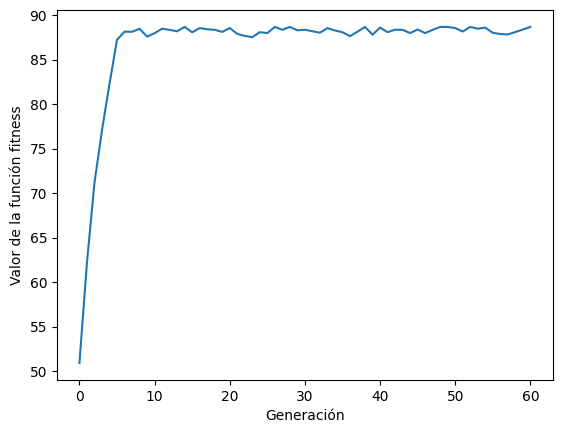

[]

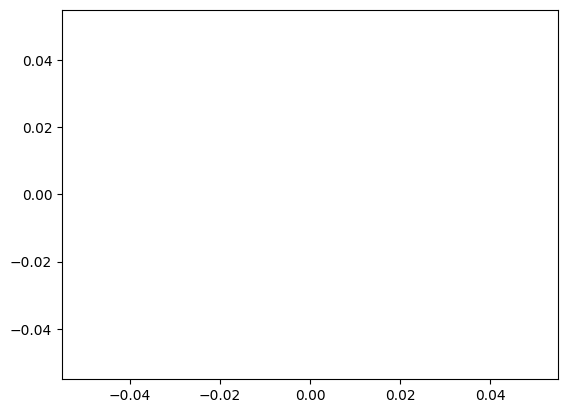

In [ ]:
generaciones = logbook.select('gen'); media = logbook.select('Media'); desviacion = logbook.select('Desviacion')
plt.plot(generaciones, media, label='Media')
plt.xlabel('Generación')
plt.ylabel('Valor de la función fitness')
plt.show()
plt.plot()


tarea: el problema de maximizar con variables 0, 10 (hacerlo a mano con numpy)
- hacerlo con la libreria

## Solucion al problema de la mochila con dos objetivos usando deap

In [ ]:
# se crea la caja de herramientas donde la libreria (deap) ira guardando los operadores geneticos
toolbox = base.Toolbox()
# definimos la clase FinessBi
# cambio
creator.create("FitnessBi", base.Fitness, weights=(-1.0, 1.0 )) # max es cuando es un solo objetivo
# se definela clase individual. Cada individuo se representa con una lista
# cambio
creator.create("Individual", list, fitness=creator.FitnessBI)
# registramos la forma de crear un 
toolbox.register("attribute", random.randint, 0, 1)
# se registra la forma de crear un individuo
# abajo se crea una lista de longitud 10
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attribute, n=10)
# abajo se crea una lista de longitud
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

In [ ]:
# construyamos ahora los operadores geneticos
# seleccion por torneo
toolbox.register("select", tools.selTournament, tournsize=3)
# registramos el crice por un punto
toolbox.register("mate", tools.cxOnePoint)
# registramos la mutacion. Inculimos la probabilidad de mutacion
toolbox.register("mutate", tools.mutFlipBit, indpb=0.1)
# definimos la funcion fitness de nuestro problema
w = np.array([1.0, 0.5, 3.0, 4.0, 2.5, 5.0, 1.5, 3.5, 2.0, 0.3])  # pesos
v = np.array([7, 10, 13, 12, 9, 15, 8, 14, 6, 4])
# la funcion debe retornar una tupla, no puede ser un numero solamente
def evaluate(ind):
    peso = np.dot(w, ind)
    valor = np.dot(v, ind)
    return peso, valor

toolbox.register("evaluate", fitness_1)
    

## Ejercicio: optimización multiobjetivo de un portafolio con algoritmos genéticos
 
Considere un conjunto de 6 activos financieros seleccionados por usted. Usando `yfinance`, descargue una serie histórica de precios ajustados para esos activos y construya sus retornos.
 
El objetivo es aproximar, mediante un algoritmo genético multiobjetivo implementado con la librería `deap`, la frontera de Pareto del problema de selección de portafolio.
 
### Planteamiento
 
Sea
 
$$
x=(x_1,\dots,x_6)
$$
 
el vector de pesos del portafolio, donde $x_i$ representa la proporción invertida en el activo $i$. Se supone que
 
$$
x_i \geq 0, \qquad i=1,\dots,6,
$$
 
y que
 
$$
\sum_{i=1}^6 x_i = 1.
$$
 
No se permiten ventas en corto.
 
A partir de los retornos históricos estimen:
 
- el vector de retornos esperados $\mu$,
- la matriz de covarianzas $\Sigma$.
 
Con estos datos, el problema biobjetivo consiste en
 
$$
\max R(x)=\mu^\top x,
\qquad
\min V(x)=x^\top \Sigma x,
$$
 
sujeto a
 
$$
x_i \geq 0, \qquad i=1,\dots,6,
\qquad
\sum_{i=1}^6 x_i = 1.
$$
 
### Actividades
 
1. Elija 6 activos y descargue sus precios ajustados con `yfinance`.
 
2. Calcule los retornos y estime el vector de retornos esperados y la matriz de covarianzas.
 
3. Implemente en `deap` un algoritmo genético multiobjetivo para aproximar la frontera de Pareto del problema.
 
4. Represente cada individuo como un vector de 6 pesos y garantice que siempre defina un portafolio válido.
 
5. Grafique la frontera de Pareto aproximada en el plano riesgo-retorno.
 
6. Reporte al menos tres portafolios obtenidos:
   - uno de bajo riesgo,
   - uno de alto retorno,
   - uno intermedio.

## Solución guiada: portafolio multiobjetivo con DEAP

El problema es que tengo 6 activos, y quiero mirar que porcentaje. de plata pongo en cada uno.

Tengo dos objetivos:
- quiero tener mas retorno,
- pero tambien quiero tener menos riesgo.

Esto es multiobjetivo porque hay dos metas al mismo tiempo.

Al no haber solo un unico "mejor" portafolio, para eso usamos la frontera de Pareto: que es un conjunto de soluciones donde no se mejora una cosa sin empeorar la otra.

El vector son los pesos del portafolio, es decir, por ej:

$x=(0.20,0.10,0.30,0.15,0.05,0.20)$

20% en el activo 1, 10% en el activo 2, 30% en el 3, etc.

- $x_i \leq 0$ : no puedo invertir porcentajes negativos.
- $\sum{x_i} = 1$: el total invertido debe ser el 100%.

**Retorno esperado:** promedio ponderado de los retornos esperados de los activos.

**Varianza:** mide el riesgo del portafolio.


### 1. Elección de activos y datos históricos

Para que el portafolio no quede concentrado en un solo sector, elegimos 6 activos conocidos y relativamente diversificados:

- `AAPL`: tecnología
- `MSFT`: tecnología
- `JNJ`: salud
- `KO`: consumo defensivo
- `JPM`: financiero
- `XOM`: energía

Usaremos precios ajustados descargados con `yfinance` en el período comprendido entre **2023-01-01** y **2026-03-01**. A partir de esos precios calcularemos los retornos diarios, y con ellos estimaremos:

- el vector de retornos esperados `mu`,
- la matriz de covarianzas `Sigma`.

Para hacer más interpretable el problema, anualizaremos ambas magnitudes usando 252 días hábiles por año.


In [ ]:
import random
from IPython.display import display
import pandas as pd
import yfinance as yf
from deap import base, creator, tools, algorithms

# fijamos semillas para que el experimento sea reproducible
random.seed(123)
np.random.seed(123)

# defino activos y su periodo de descarga
tickers = ['AAPL', 'MSFT', 'JNJ', 'KO', 'JPM', 'XOM']
start_date = '2023-01-01'
end_date = '2026-03-01'

# descargamos activos y series de cierre
series = []
for ticker in tickers:
    datos = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False, timeout=30)
    # en esta versión de yfinance el cierre puede venir con MultiIndex
    cierre = datos[('Close', ticker)] if isinstance(datos.columns, pd.MultiIndex) else datos['Close']
    series.append(cierre.rename(ticker))

# uno todas las series en un df, cada columna siendo un activo y cada fila un registro por fecha
precios = pd.concat(series, axis=1).dropna()
# para calcular retornos porcentuales diarios para cada dia
retornos = precios.pct_change().dropna()


# estimaciones anualizadas: retorno promedio diario de cada activo, anualizando por 252 dias habiles
mu = retornos.mean() * 252 # vector de 6 componentes
Sigma = retornos.cov() * 252 # matriz de covarianzas anualizada

# diagonal: varianza de cada activo
# fuera de diagonal:  como se mueven juntos dos activos.

print('Precios descargados:')
display(precios.head())
print('Retornos diarios:')
display(retornos.head())
print('Retorno esperado anual de cada activo:')
display(mu)
print('Matriz de covarianzas anualizada:')
display(Sigma)


Precios descargados:


,AAPL,MSFT,JNJ,KO,JPM,XOM
Date,,,,,,
2023-01-03,123.096031,233.452805,161.795807,57.126358,124.928703,95.434212
2023-01-04,124.365669,223.240829,163.557297,57.099125,126.093666,95.711967
2023-01-05,123.046806,216.624451,162.349640,56.445740,126.065720,97.853424
2023-01-06,127.574219,219.177444,163.666214,57.534721,128.478058,99.036179
2023-01-09,128.095825,221.311447,159.425903,56.817799,127.947159,97.190376


Retornos diarios:


,AAPL,MSFT,JNJ,KO,JPM,XOM
Date,,,,,,
2023-01-04,0.010314,-0.043743,0.010887,-0.000477,0.009325,0.002910
2023-01-05,-0.010605,-0.029638,-0.007384,-0.011443,-0.000222,0.022374
2023-01-06,0.036794,0.011785,0.008109,0.019293,0.019136,0.012087
2023-01-09,0.004089,0.009736,-0.025908,-0.012461,-0.004132,-0.018638
2023-01-10,0.004457,0.007617,-0.002392,-0.007666,0.008954,0.014935


Retorno esperado anual de cada activo:


AAPL    0.276491
MSFT    0.195190
JNJ     0.151619
KO      0.122524
JPM     0.307209
XOM     0.176230
dtype: float64

Matriz de covarianzas anualizada:


,AAPL,MSFT,JNJ,KO,JPM,XOM
AAPL,0.066124,0.027820,0.002429,0.004654,0.018428,0.010204
MSFT,0.027820,0.058496,-0.003770,-0.001159,0.013723,-0.001446
JNJ,0.002429,-0.003770,0.029627,0.010226,0.004761,0.006477
KO,0.004654,-0.001159,0.010226,0.022252,0.002715,0.005302
JPM,0.018428,0.013723,0.004761,0.002715,0.054683,0.017217
XOM,0.010204,-0.001446,0.006477,0.005302,0.017217,0.053305


### 2. Representación del individuo

Cada individuo será un vector de 6 pesos:

$$
x=(x_1,\dots,x_6)
$$

donde cada componente cumple `x_i >= 0` y además los pesos deben sumar 1.

Eso significa que **cada individuo debe representar siempre un portafolio válido**. Para garantizarlo usaremos una función de **reparación**:

- recorta pesos negativos,
- y luego normaliza para que la suma total sea 1.

Así, aunque después del cruce o la mutación un individuo quede “desajustado”, lo corregimos antes de evaluarlo.


In [44]:
n_activos = len(tickers) #6

def reparar_pesos(w):
    """Asegura que un vector defina un portafolio válido."""
    w = np.clip(np.asarray(w, dtype=float), 0.0, None) # recorta todos los valores activos menores que 0 y los pone en 0
    suma = w.sum() # sumar pesos
    if suma <= 1e-12: # si es 0
        # creamos un portafolio uniforme
        w = np.ones(n_activos) / n_activos
    else:
        w = w / suma # dividimos cada componente por la suma total, para que queden normalizados y sumen 1
    return w

def retorno_portafolio(w): # retorno esperado del portafolio
    w = reparar_pesos(w)
    return float(mu.values @ w) # producto punto entre el vector de retornos esperados y el vector de pesos del portafolio, para obtener el retorno esperado del portafolio
    # mu t w

def varianza_portafolio(w):
    w = reparar_pesos(w)
    return float(w @ Sigma.values @ w) # w t Sigma w, varianza del portafolio

ejemplo_w = reparar_pesos([0.2, 0.1, 0.4, 0.1, 0.1, 0.1])
print('Pesos de ejemplo:', ejemplo_w)
print('Suma de pesos:', ejemplo_w.sum())
print('Retorno esperado anual:', retorno_portafolio(ejemplo_w))
print('Varianza anual:', varianza_portafolio(ejemplo_w))


Pesos de ejemplo: [0.2 0.1 0.4 0.1 0.1 0.1]
Suma de pesos: 1.0
Retorno esperado anual: 0.19606112503987466
Varianza anual: 0.014248082851215316


### 3. Algoritmo genético multiobjetivo

Ahora usamos `DEAP` para aproximar la frontera de Pareto.

En este problema tenemos dos objetivos:

- **maximizar** el retorno esperado $R(x)=\mu^\top x$,
- **minimizar** la varianza $V(x)=x^\top \Sigma x$.

En `DEAP` esto se indica con pesos de fitness `(1.0, -1.0)`: positivo para maximizar retorno y negativo para minimizar varianza.

Usaremos una versión tipo **NSGA-II**, que es uno de los métodos más clásicos en optimización multiobjetivo. La idea general es:

1. crear una población inicial de portafolios válidos,
2. evaluar retorno y varianza,
3. generar descendencia mediante cruce y mutación,
4. quedarse con los mejores individuos no dominados, preservando diversidad en la frontera.


In [39]:
# usamos nombres nuevos para no chocar con posibles clases creadas antes en el notebook
if not hasattr(creator, 'FitnessPortafolio'):
    creator.create('FitnessPortafolio', base.Fitness, weights=(1.0, -1.0))
if not hasattr(creator, 'IndividualPortafolio'):
    creator.create('IndividualPortafolio', list, fitness=creator.FitnessPortafolio)

def crear_individuo():
    # Dirichlet genera directamente un vector positivo que suma 1
    pesos = np.random.dirichlet(np.ones(n_activos))
    return creator.IndividualPortafolio(pesos.tolist())

def evaluar_portafolio(individual):
    w = reparar_pesos(individual)
    retorno = float(mu.values @ w)
    varianza = float(w @ Sigma.values @ w)
    return retorno, varianza

def cruce_aritmetico(ind1, ind2):
    p1 = np.array(ind1, dtype=float)
    p2 = np.array(ind2, dtype=float)
    lam = np.random.uniform(0, 1, size=n_activos)
    h1 = reparar_pesos(lam*p1 + (1 - lam)*p2)
    h2 = reparar_pesos((1 - lam)*p1 + lam*p2)
    ind1[:] = h1.tolist()
    ind2[:] = h2.tolist()
    return ind1, ind2

def mutacion_gaussiana(individual, sigma=0.05, indpb=0.4):
    w = np.array(individual, dtype=float)
    mascara = np.random.rand(n_activos) < indpb
    if mascara.any():
        w[mascara] += np.random.normal(0, sigma, size=mascara.sum())
    w = reparar_pesos(w)
    individual[:] = w.tolist()
    return (individual,)

toolbox = base.Toolbox()
toolbox.register('individual', crear_individuo)
toolbox.register('population', tools.initRepeat, list, toolbox.individual)
toolbox.register('evaluate', evaluar_portafolio)
toolbox.register('mate', cruce_aritmetico)
toolbox.register('mutate', mutacion_gaussiana, sigma=0.04, indpb=0.4)
toolbox.register('select', tools.selNSGA2)


In [40]:
# parámetros del algoritmo
MU = 80      # tamaño de población
LAMBDA = 80  # número de descendientes
NGEN = 50    # generaciones
CXPB = 0.9   # probabilidad de cruce
MUTPB = 0.2  # probabilidad de mutación

poblacion = toolbox.population(n=MU)

# evaluación inicial
invalidos = [ind for ind in poblacion if not ind.fitness.valid]
for ind, fit in zip(invalidos, map(toolbox.evaluate, invalidos)):
    ind.fitness.values = fit

# NSGA-II asigna ranking y crowding distance
poblacion = toolbox.select(poblacion, len(poblacion))

hist_ret = []
hist_var = []

for gen in range(NGEN):
    descendencia = tools.selTournamentDCD(poblacion, LAMBDA)
    descendencia = [toolbox.clone(ind) for ind in descendencia]

    descendencia = algorithms.varAnd(descendencia, toolbox, cxpb=CXPB, mutpb=MUTPB)

    invalidos = [ind for ind in descendencia if not ind.fitness.valid]
    for ind, fit in zip(invalidos, map(toolbox.evaluate, invalidos)):
        ind.fitness.values = fit

    poblacion = toolbox.select(poblacion + descendencia, MU)

    fit_actual = np.array([ind.fitness.values for ind in poblacion])
    hist_ret.append(fit_actual[:, 0].max())
    hist_var.append(fit_actual[:, 1].min())

frente_pareto = tools.sortNondominated(poblacion, len(poblacion), first_front_only=True)[0]
pareto_df = pd.DataFrame({
    'retorno': [ind.fitness.values[0] for ind in frente_pareto],
    'varianza': [ind.fitness.values[1] for ind in frente_pareto],
    'riesgo': [np.sqrt(ind.fitness.values[1]) for ind in frente_pareto]
})

print('Número de portafolios en la frontera aproximada:', len(frente_pareto))
pareto_df.sort_values(['riesgo', 'retorno']).head()


Número de portafolios en la frontera aproximada: 80


,retorno,varianza,riesgo
0,0.177105,0.011365,0.106608
25,0.177425,0.011376,0.106660
6,0.181599,0.011585,0.107633
57,0.183606,0.011720,0.108259
8,0.184775,0.011762,0.108452


### 4. Frontera de Pareto aproximada

La frontera de Pareto representa el conjunto de portafolios para los cuales **no se puede mejorar un objetivo sin empeorar el otro**.

En el gráfico, cada punto será un portafolio no dominado. En el eje `x` usaremos el **riesgo** medido como desviación estándar:

$$
\sigma(x) = \sqrt{x^\top \Sigma x}
$$

y en el eje `y` el **retorno esperado**.


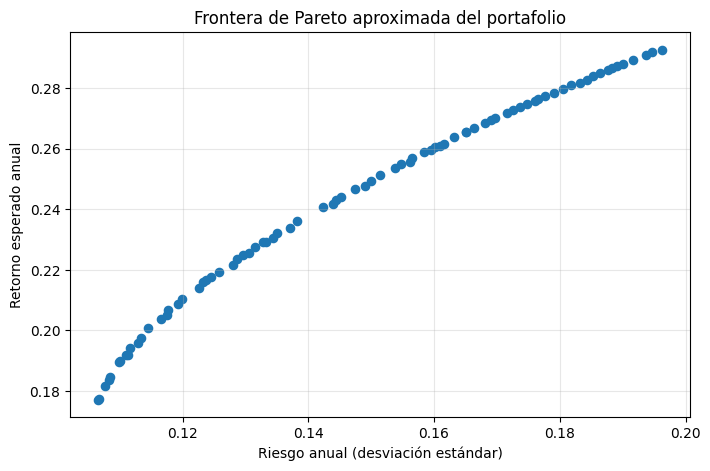

In [41]:
pareto_df = pareto_df.sort_values('riesgo').reset_index(drop=True)

plt.figure(figsize=(8, 5))
plt.scatter(pareto_df['riesgo'], pareto_df['retorno'], c='tab:blue', s=35)
plt.xlabel('Riesgo anual (desviación estándar)')
plt.ylabel('Retorno esperado anual')
plt.title('Frontera de Pareto aproximada del portafolio')
plt.grid(alpha=0.3)
plt.show()


In [42]:
# seleccionamos tres portafolios representativos de la frontera
idx_bajo_riesgo = pareto_df['riesgo'].idxmin()
idx_alto_retorno = pareto_df['retorno'].idxmax()

# portafolio intermedio: cercano al punto medio en riesgo-retorno normalizados
riesgo_norm = (pareto_df['riesgo'] - pareto_df['riesgo'].min()) / (pareto_df['riesgo'].max() - pareto_df['riesgo'].min() + 1e-12)
ret_norm = (pareto_df['retorno'] - pareto_df['retorno'].min()) / (pareto_df['retorno'].max() - pareto_df['retorno'].min() + 1e-12)
idx_intermedio = ((riesgo_norm - 0.5)**2 + (ret_norm - 0.5)**2).idxmin()

seleccionados = {
    'bajo_riesgo': frente_pareto[int(idx_bajo_riesgo)],
    'alto_retorno': frente_pareto[int(idx_alto_retorno)],
    'intermedio': frente_pareto[int(idx_intermedio)]
}

filas = []
for nombre, ind in seleccionados.items():
    w = np.array(ind, dtype=float)
    filas.append({
        'portafolio': nombre,
        'retorno': ind.fitness.values[0],
        'varianza': ind.fitness.values[1],
        'riesgo': np.sqrt(ind.fitness.values[1]),
        **{ticker: peso for ticker, peso in zip(tickers, w)}
    })

resumen_portafolios = pd.DataFrame(filas)
resumen_portafolios


,portafolio,retorno,varianza,riesgo,AAPL,MSFT,JNJ,KO,JPM,XOM
0,bajo_riesgo,0.177105,0.011365,0.106608,0.045867,0.178385,0.225006,0.310776,0.115454,0.124512
1,alto_retorno,0.192014,0.012390,0.111309,0.056414,0.166751,0.280814,0.201046,0.188386,0.106589
2,intermedio,0.225586,0.017064,0.130628,0.171948,0.149075,0.194005,0.129376,0.313122,0.042475


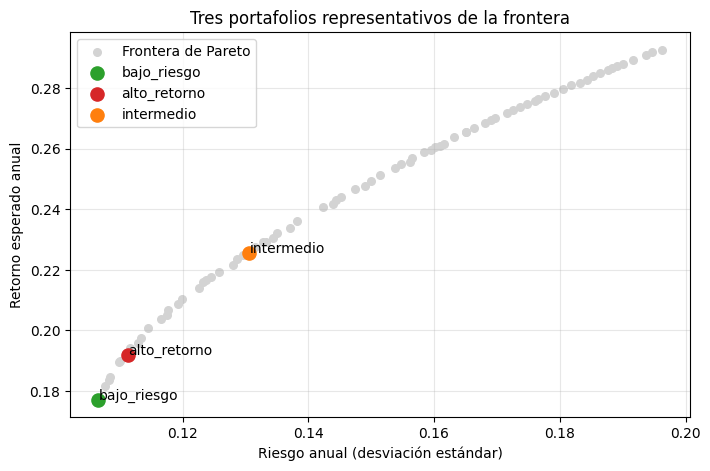

In [43]:
plt.figure(figsize=(8, 5))
plt.scatter(pareto_df['riesgo'], pareto_df['retorno'], c='lightgray', s=30, label='Frontera de Pareto')

colores = {'bajo_riesgo': 'tab:green', 'intermedio': 'tab:orange', 'alto_retorno': 'tab:red'}
for _, fila in resumen_portafolios.iterrows():
    plt.scatter(fila['riesgo'], fila['retorno'], c=colores[fila['portafolio']], s=90, label=fila['portafolio'])
    plt.text(fila['riesgo'], fila['retorno'], fila['portafolio'])

plt.xlabel('Riesgo anual (desviación estándar)')
plt.ylabel('Retorno esperado anual')
plt.title('Tres portafolios representativos de la frontera')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


### 5. ¿Cómo explicar el resultado en clase?

Una forma sencilla de exponerlo es esta:

1. **Construimos los datos** con precios ajustados y retornos diarios de 6 activos.
2. **Estimamos** el retorno esperado y el riesgo histórico con `mu` y `Sigma`.
3. **Codificamos cada portafolio** como un vector de pesos que siempre suma 1 y no tiene ventas en corto.
4. **Evaluamos dos objetivos al mismo tiempo**: queremos más retorno y menos varianza.
5. **Usamos NSGA-II en DEAP** para generar muchos portafolios candidatos y conservar los no dominados.
6. **La salida no es una sola solución**, sino una frontera de Pareto: un conjunto de compromisos entre riesgo y retorno.

La idea central del ejercicio es que, en problemas multiobjetivo, no siempre existe un único “mejor” portafolio. Lo que obtenemos es una familia de soluciones eficientes, y luego el inversionista elige según su perfil de riesgo.
